In [1]:
import json
from datetime import datetime
import pycountry
from matplotlib import pyplot as plt
import pycountry_convert as pc

from emu_renewal.inputs import DATA_PATH, get_dec_pooled_totals, get_continent_data, get_continent_vars, get_country_vars, extract_specific_var
from emu_renewal.run import find_run_end_time, get_country_vacc_data

In [2]:
countries = json.load(open(DATA_PATH / f"config/included.json", "r"))
date_threshold = datetime(2021, 4, 1)
vacc_thresh = 0.05
delta_countries = []
for c in countries:
    vacc_data = get_country_vacc_data(c)
    end_time = find_run_end_time(vacc_data, vacc_thresh, c)
    if end_time > date_threshold:
        delta_countries.append(c)

In [3]:
from emu_renewal.inputs import get_alpha_target, get_cosine_intercept, get_delta_target

In [22]:
iso3 = "BGR"
iso2 = pycountry.countries.lookup(iso3).alpha_2
continent = pc.country_alpha2_to_continent_code(iso2)
var_data = get_country_vars(iso3)

In [23]:
vacc_data = get_country_vacc_data(iso3)

In [24]:
end_time = find_run_end_time(vacc_data, 0.05, "BGR")

In [37]:
max(delta_targ) > 0.05

0.002232142857142857

In [35]:
delta_data = extract_specific_var(var_data, "delta")
max(delta_data.loc[delta_data.index < datetime(2021, 7, 1), "delta_prop"]) > 0.05

True

In [32]:
delta_data

,delta,totals,delta_prop
2021-03-29,1.0,448.0,0.002232
2021-06-07,23.0,91.0,0.252747
2021-06-21,88.0,165.0,0.533333
2021-07-05,127.0,154.0,0.824675
2021-07-19,367.0,372.0,0.986559
2021-08-02,602.0,606.0,0.993399
2021-08-16,931.0,932.0,0.998927
2021-09-27,960.0,961.0,0.998959
2021-12-06,734.0,739.0,0.993234
2021-12-20,354.0,517.0,0.684720


<Axes: >

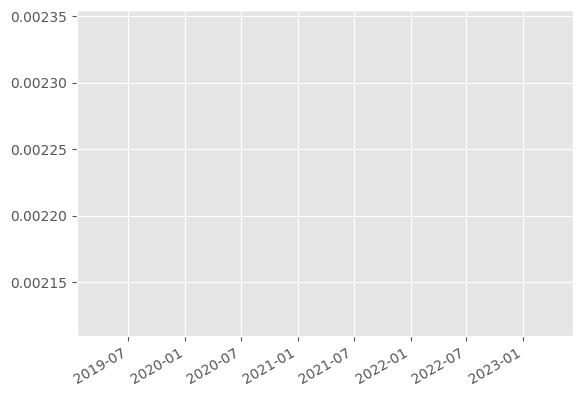

In [26]:
delta_targ = get_delta_target(var_data, continent, end_time)
delta_targ.plot()

In [9]:
delta_targ

2021-02-15    0.026726
2021-03-01    0.142113
2021-03-15    0.196549
2021-03-29    0.521719
2021-04-12    0.779136
2021-04-26    0.905157
2021-05-10    0.980285
2021-05-24    0.987521
Name: delta_prop, dtype: float64

<Axes: >

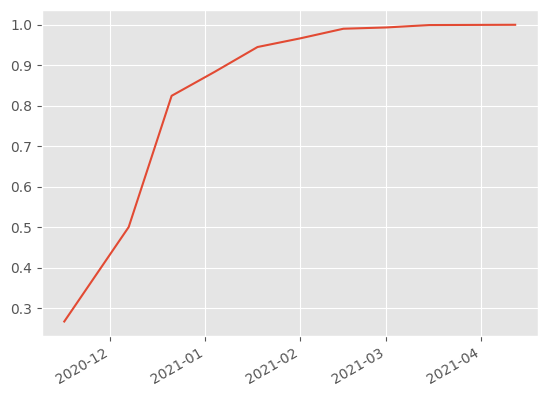

In [11]:
alpha_targ = get_alpha_target(var_data, continent, end_time)
alpha_targ.plot()

In [12]:
get_cosine_intercept(alpha_targ, 0)

datetime.datetime(2020, 8, 7, 0, 0)

In [ ]:
BA5_PERIOD_START = datetime(2022, 4, 1)
BA5_PERIOD_END = datetime(2022, 9, 1)
def get_ba5_target(var_data, continent):
    if continent == "OC":
        ba2_data = extract_specific_var(var_data, "ba5")
        period_mask = (BA5_PERIOD_START < ba2_data.index) & (ba2_data.index < BA5_PERIOD_END)
        filt_data = ba2_data[period_mask]
        return filt_data["ba5_prop"]

In [ ]:
get_ba5_target(var_data, continent).plot()

In [ ]:
from emu_renewal.utils import get_row_proportions

In [ ]:
late_data = var_data[(datetime(2022, 4, 1) < var_data.index) & (var_data.index < datetime(2022, 9, 1))]
late_data = late_data[[c for c in late_data.columns if late_data[c].sum() > 0.0]]
get_row_proportions(late_data).plot.area()

In [ ]:

for c in delta_countries[:1]:
    country = pycountry.countries.lookup(c).name
    print(country)
    var_data = get_country_vars(c)
    delta_data = extract_specific_var(var_data, "delta")
    if delta_data is None:
        iso2 = pycountry.countries.lookup(c).alpha_2
        continent = pc.country_alpha2_to_continent_code(iso2)
        cont_data = get_continent_data(continent, "delta")
        delta_data = get_continent_vars(cont_data, "delta")
    filt_data = delta_data[(start < delta_data.index) & (delta_data.index < end)]
    pooled_data = get_dec_pooled_totals(filt_data, "delta")
    plt.figure()
    filt_data["delta_prop"].plot()
    pooled_data["delta_prop"].plot()
    plt.title(country)